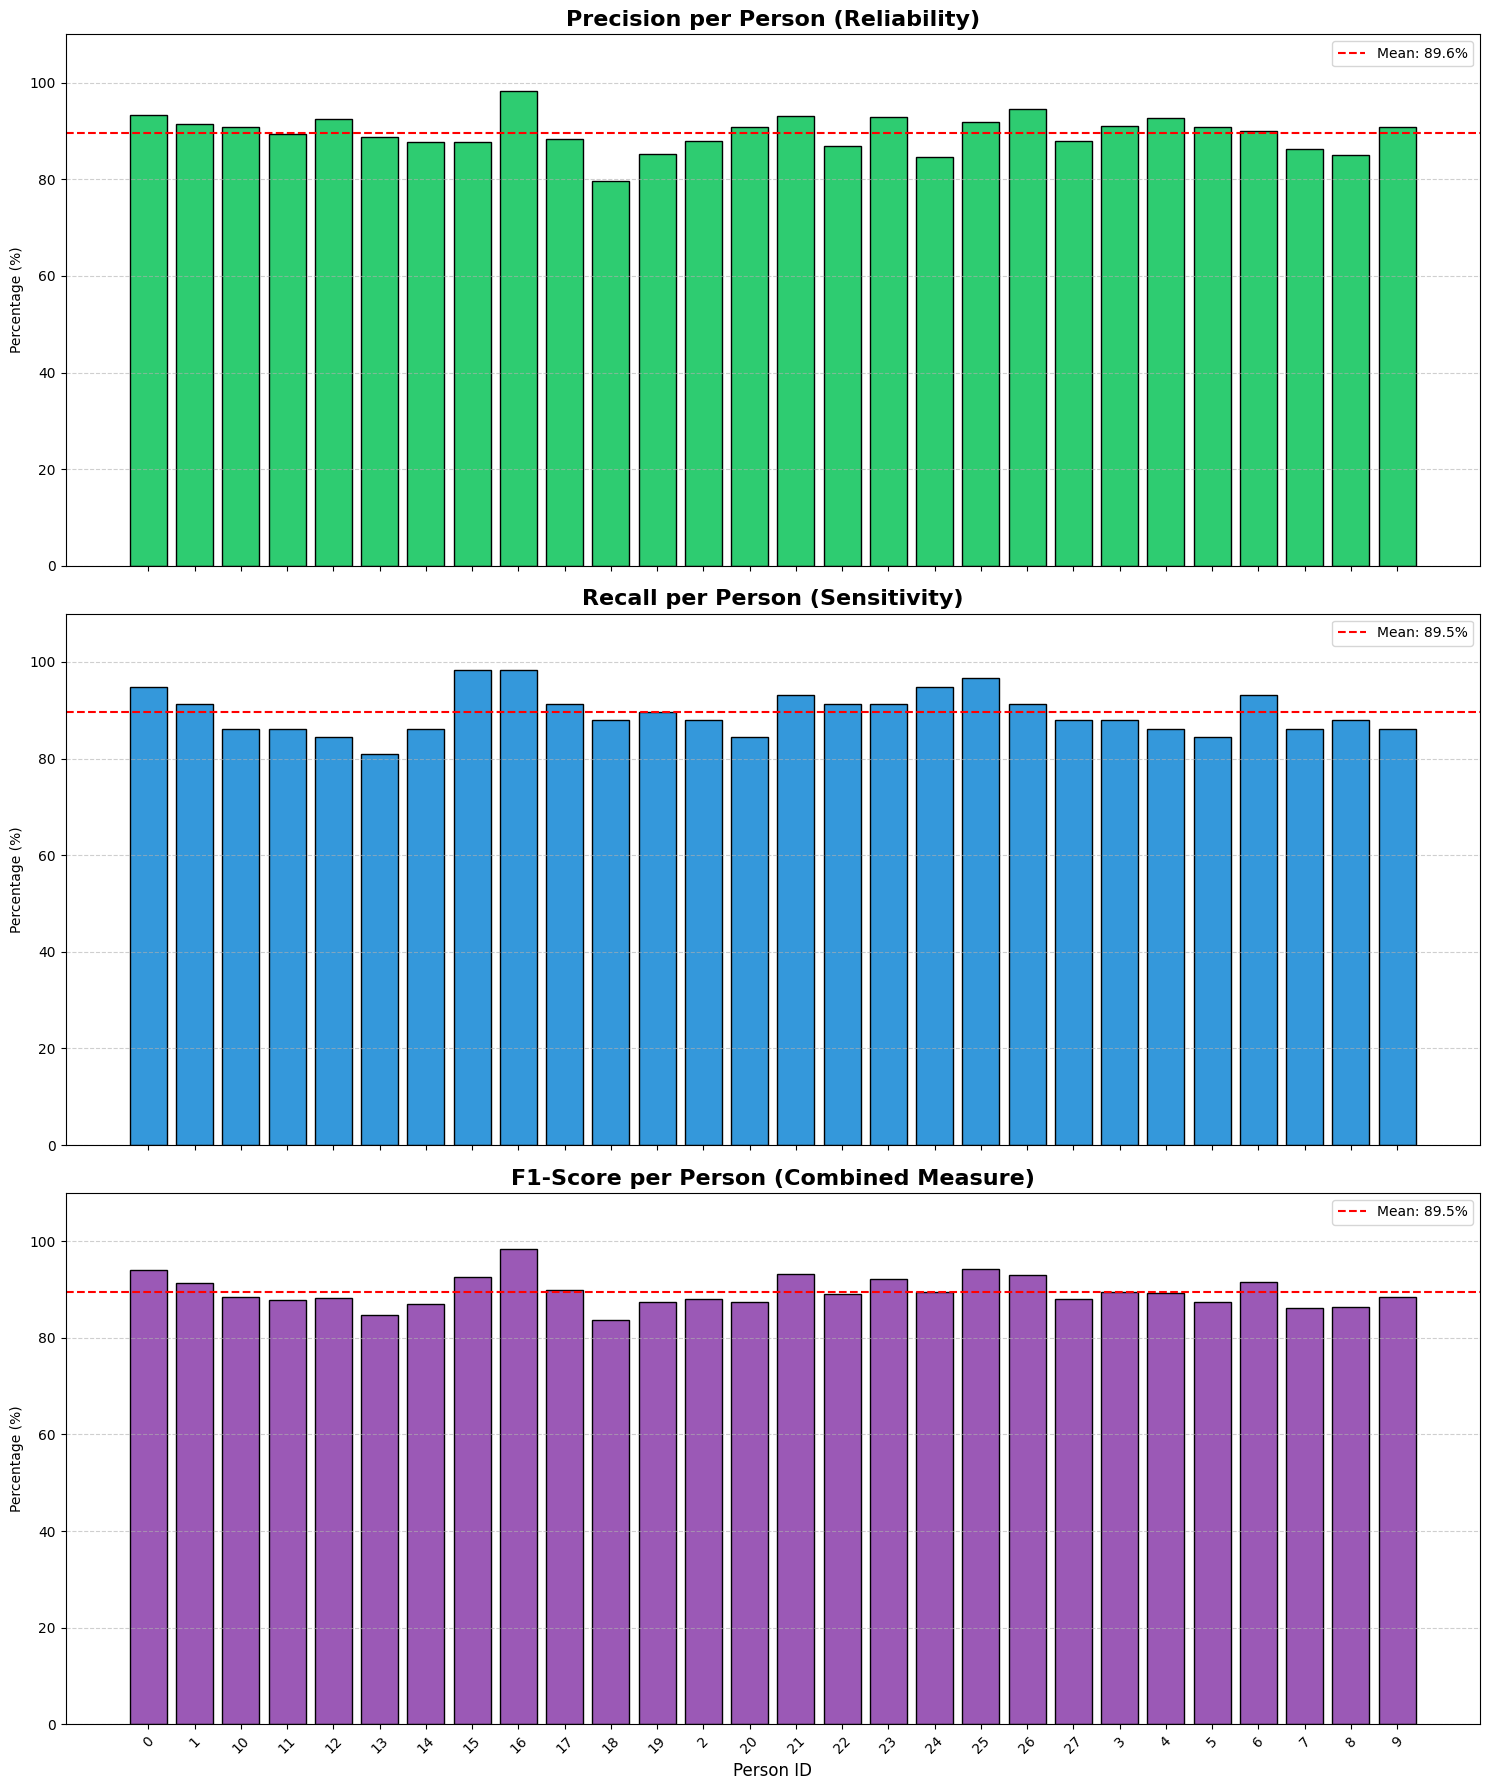

In [2]:
import numpy as np
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

alg = input("What algorithm should I benchmark?\n")
y_test = np.load('data/y_test.npz')['data']
y_pred = np.load(f'data/y_pred_{alg}.npz')['data']

# 1. Generate the classification report as a dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# 2. Convert to DataFrame and clean up
# We remove 'accuracy', 'macro avg', and 'weighted avg' to keep only the 28 people
metrics_df = pd.DataFrame(report).transpose()
metrics_df = metrics_df.drop(['accuracy', 'macro avg', 'weighted avg'])

# Add 'accuracy' column per person (in multi-class, Recall is often equivalent
# to per-class accuracy, but we'll plot the three standard metrics)
metrics_df = metrics_df[['precision', 'recall', 'f1-score']] * 100
metrics_df = metrics_df.sort_index() # Keep people in order p1, p2...

# 3. Plotting
fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)

metrics = ['precision', 'recall', 'f1-score']
colors = ['#2ecc71', '#3498db', '#9b59b6']
titles = ['Precision per Person (Reliability)',
          'Recall per Person (Sensitivity)',
          'F1-Score per Person (Combined Measure)']

for i, metric in enumerate(metrics):
    axes[i].bar(metrics_df.index, metrics_df[metric], color=colors[i], edgecolor='black')
    axes[i].set_title(titles[i], fontsize=16, fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_ylim(0, 110)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

    # Add a horizontal line for the average
    avg_val = metrics_df[metric].mean()
    axes[i].axhline(avg_val, color='red', linestyle='--', label=f'Mean: {avg_val:.1f}%')
    axes[i].legend()

plt.xticks(rotation=45)
plt.xlabel('Person ID', fontsize=12)
plt.tight_layout()
plt.show()